In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from config import config
import torch
import os
os.chdir(config.paths.roots.project)

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

In [4]:
dm.prepare_data()
dm.setup(stage='fit')

INFO     | setup | Train Dataset       : 15 samples
INFO     | setup | Validation Dataset  : 4 samples


In [5]:
dl = dm.train_dataloader()

In [6]:
batch = next(iter(dl))

In [7]:
reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

image_level_reference_coords = batch.image_level_reference_coords
image_level_target_coords = batch.image_level_target_coords
print(image_level_reference_coords.shape, image_level_target_coords.shape)

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

torch.Size([80, 3, 32, 32]) torch.Size([80, 3, 32, 32])
torch.Size([80, 2]) torch.Size([80, 2])
torch.Size([80, 2]) torch.Size([80, 2])


In [8]:
patch_level_reference_coords.min().item(), patch_level_reference_coords.max().item()

(16, 16)

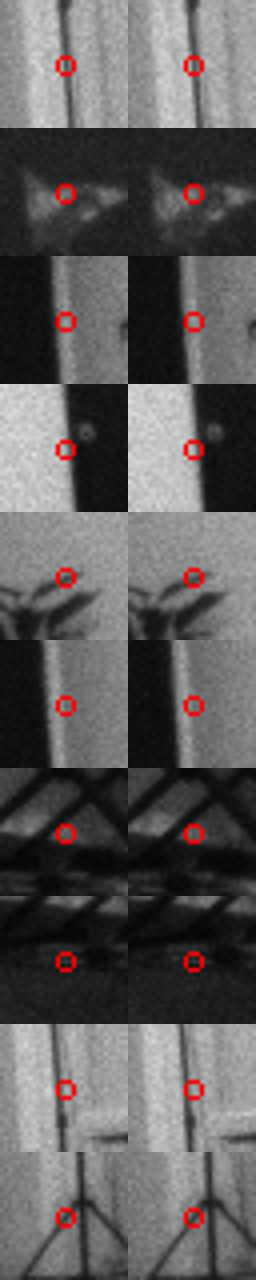

In [9]:
from utils import show_batch
show_batch(reference_patches, target_patches, limit_count=10)

In [10]:
dm.teardown()

# Check Model

In [11]:
# samples = torch.randn_like(reference_patches)
# samples.shape

In [12]:
# from src import DescriptorModel
# model = DescriptorModel()

In [13]:
# out = model(samples)
# out.shape